In [1]:
# pip install matplotlib

In [2]:
# pip install -U ultralytics

In [3]:
# pip install pandas

In [4]:
# pip install scikit-learn

## 1. Importing the Required Libraries

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
from ultralytics import YOLO

## 2. Importing the Data

### 2.1. Training Data

Mild: 4746 images
Moderate: 5000 images
Normal: 5224 images
Proliferate: 5200 images
Severe: 5000 images


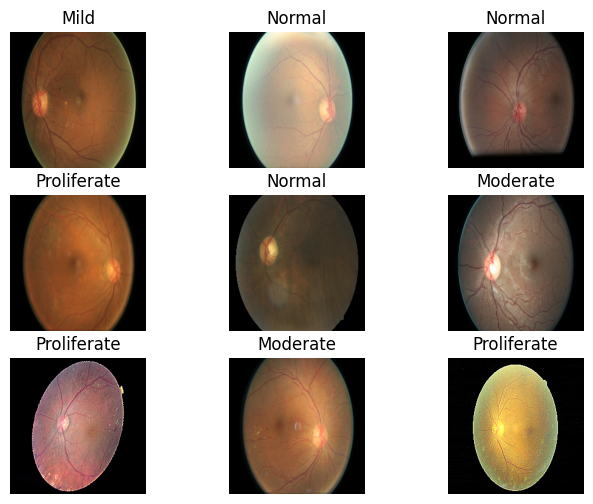

In [7]:
train_dir = "./OCT diabetic images/train"

for cls in sorted(os.listdir(train_dir)):
    path = os.path.join(train_dir, cls)
    if not os.path.isdir(path):
        continue
    count = len(os.listdir(path))
    print(f"{cls}: {count} images")

classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

plt.figure(figsize=(8, 6))
for i in range(9):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(train_dir, cls)))
    img_path = os.path.join(train_dir, cls, img_name)

    img = Image.open(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cls)
plt.show()

### 2.2. Validation Data

Mild: 140 images
Moderate: 292 images
Normal: 295 images
Proliferate: 296 images
Severe: 238 images


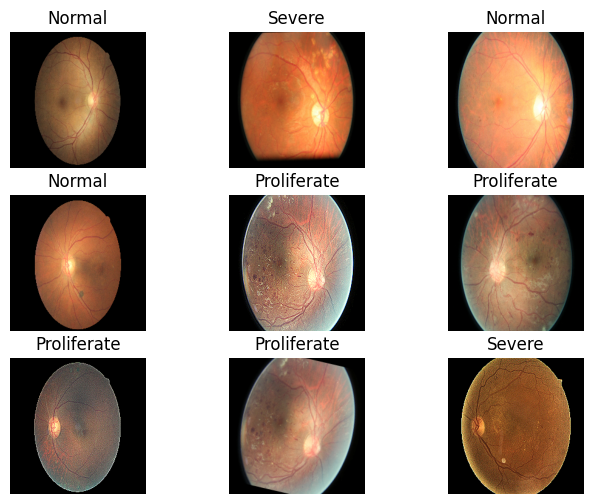

In [30]:
val_dir = "./OCT diabetic images/val"

for cls in sorted(os.listdir(val_dir)):
    path = os.path.join(val_dir, cls)
    if not os.path.isdir(path):
        continue
    count = len(os.listdir(path))
    print(f"{cls}: {count} images")

classes = [d for d in os.listdir(val_dir) if os.path.isdir(os.path.join(val_dir, d))]

plt.figure(figsize=(8, 6))
for i in range(9):
    cls = random.choice(classes)
    img_name = random.choice(os.listdir(os.path.join(val_dir, cls)))
    img_path = os.path.join(val_dir, cls, img_name)

    img = Image.open(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cls)
plt.show()

## 3. Visualize Statistics of the Dataset

### 3.1. Show Sample Images per Class

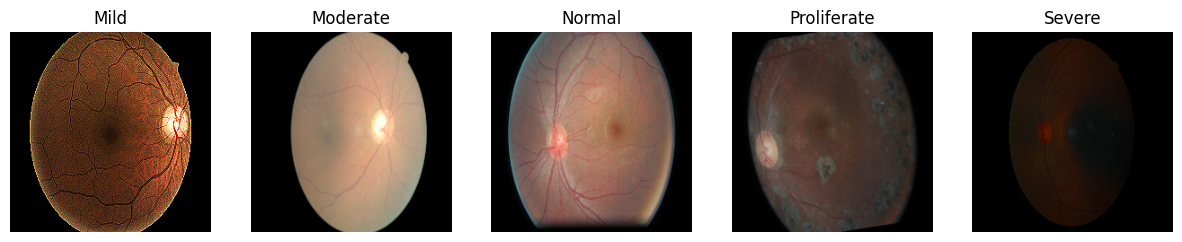

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "./OCT diabetic images/train"

# Get actual class folders
classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

plt.figure(figsize=(15, 8))

for i, cls in enumerate(sorted(classes)):
    path = os.path.join(train_dir, cls)
    if not os.path.isdir(path):
        continue
    class_path = os.path.join(train_dir, cls)
    sample_img = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, sample_img))

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.show()

### 3.2. Count how many images are in each category

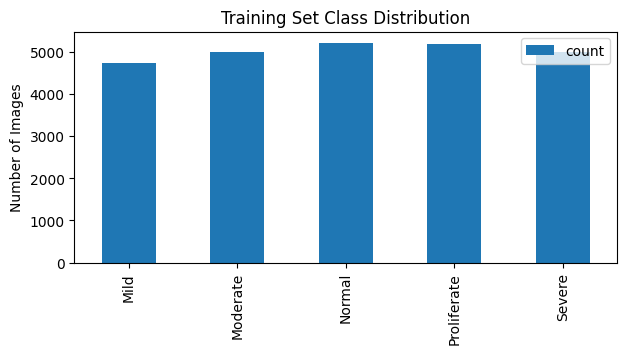

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_dir = "./OCT diabetic images/train"

counts = {}

for cls in sorted(os.listdir(train_dir)):
    path = os.path.join(train_dir, cls)
    if not os.path.isdir(path):
        continue
    cls_path = os.path.join(base_dir, cls)
    counts[cls] = len(os.listdir(cls_path))

df = pd.DataFrame.from_dict(counts, orient='index', columns=['count'])

df.plot(kind='bar', figsize=(7,3))
plt.title("Training Set Class Distribution")
plt.ylabel("Number of Images")
plt.show()


### 3.3. Pixel intensity range of images in each category

Mild: hist length=256, bin_edges length=256
Moderate: hist length=256, bin_edges length=256
Normal: hist length=256, bin_edges length=256
Proliferate: hist length=256, bin_edges length=256
Severe: hist length=256, bin_edges length=256


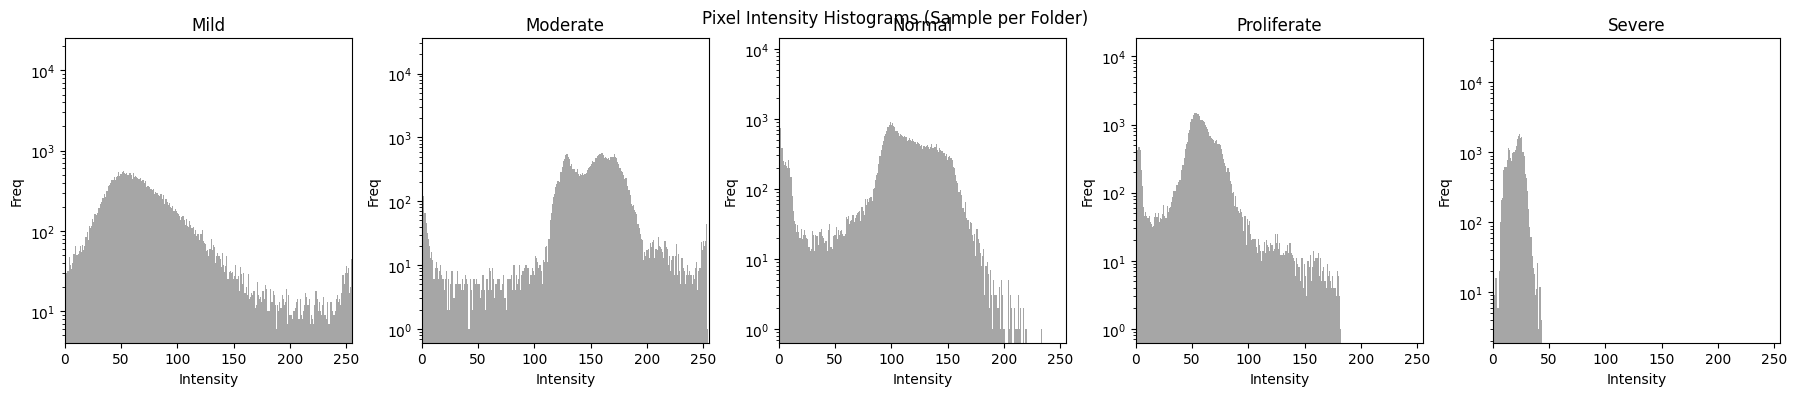

In [12]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

root_dir = "./OCT diabetic images/train"
folder_names = ["Mild", "Moderate", "Normal", "Proliferate", "Severe"]

plt.figure(figsize=(18, 4))

for i, folder in enumerate(folder_names):
    folder_path = os.path.join(root_dir, folder)
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    if not image_files:
        print(f"No images in {folder}")
        continue
    img_path = os.path.join(folder_path, image_files[0])
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)
    pixels = img_array.flatten()

    # Pure Python histogram
    hist = [0] * 256
    for v in pixels:
        if 0 <= v < 256:
            hist[int(v)] += 1
    bin_edges = list(range(256))

    print(f"{folder}: hist length={len(hist)}, bin_edges length={len(bin_edges)}")

    plt.subplot(1, 5, i+1)
    plt.bar(bin_edges, hist, color='gray', alpha=0.7, width=1)
    plt.yscale('log')

    plt.title(folder)
    plt.xlabel("Intensity")
    plt.ylabel("Freq")
    plt.xlim(0, 255)

plt.tight_layout()
plt.suptitle("Pixel Intensity Histograms (Sample per Folder)")
plt.show()


## 4. Train the Model (YOLOv8)

In [9]:
# from ultralytics import YOLO

# # Load YOLOv8 pretrained on ImageNet
# model = YOLO("yolov8s-cls.pt")

# # Train directly on directory (no YAML)
# model.train(
#     data="./OCT diabetic images",  # ✅ dataset root folder
#     epochs=30,
#     imgsz=224
# )


### 4.1 Creating seperate training set taking 100 images from each category to train model faster

In [13]:
import os
import shutil
import random

src_dir = './OCT diabetic images/train'
dst_dir = './oct_100_per_class'
train_dir = os.path.join(dst_dir, 'train')
val_dir = os.path.join(dst_dir, 'val')
n_per_class = 100
val_split = 0.2

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)


for class_name in os.listdir(src_dir):
    src_class_p = os.path.join(src_dir, class_name)
    if not os.path.isdir(src_class_p): continue
    imgs = [f for f in os.listdir(src_class_p) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tiff'))]
    sampled = random.sample(imgs, min(n_per_class, len(imgs)))
    n_val = int(len(sampled) * val_split)
    train_imgs, val_imgs = sampled[n_val:], sampled[:n_val]

    dst_class_train = os.path.join(train_dir, class_name)
    dst_class_val = os.path.join(val_dir, class_name)
    os.makedirs(dst_class_train, exist_ok=True)
    os.makedirs(dst_class_val, exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(src_class_p, img), os.path.join(dst_class_train, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_class_p, img), os.path.join(dst_class_val, img))

### 4.2. Training the model with 100 images from each category to train model faster

In [14]:
from ultralytics import YOLO
model = YOLO("yolov8s-cls.pt")
model.train(
    data="./oct_100_per_class",  # Directory co₹ntaining train/ and val/
    epochs=30,
    imgsz=224
)

New https://pypi.org/project/ultralytics/8.3.240 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.230 🚀 Python-3.14.0 torch-2.9.0 CPU (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./oct_100_per_class, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train14, nbs=64, nms=False, opset=None, optimize=False, optimi

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x1279859b0>
curves: []
curves_results: []
fitness: 0.8233333230018616
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.6466666460037231, 'metrics/accuracy_top5': 1.0, 'fitness': 0.8233333230018616}
save_dir: PosixPath('/opt/homebrew/runs/classify/train14')
speed: {'preprocess': 0.0018366666821142037, 'inference': 58.92638416664946, 'loss': 0.0011876367352670059, 'postprocess': 0.002328203287712919}
task: 'classify'
top1: 0.6466666460037231
top5: 1.0

## 5. Validating and Determining the Accuracy of the Trained Model

### 5.1. Top 1 and Top 5 Accuracy

In [26]:
# Run validation
results = model.val(data="./oct_100_per_class", imgsz=224)

# Access top-1 and top-5 accuracies from results
print("Top-1 Accuracy:", results.top1)
print("Top-5 Accuracy:", results.top5)

Ultralytics 8.3.230 🚀 Python-3.14.0 torch-2.9.0 CPU (Apple M1)
ERROR ❌ train: /Users/nilotpalbose/Documents/University/Design Workshop/Diabetic Retinopathy/oct_100_per_class/train... found 1295 images in 7 classes (requires 5 classes, not 7)
ERROR ❌ val: /Users/nilotpalbose/Documents/University/Design Workshop/Diabetic Retinopathy/oct_100_per_class/val... found 300 images in 6 classes (requires 5 classes, not 6)
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 166.7±55.0 MB/s, size: 70.4 KB)
val: Scanning /Users/nilotpalbose/Documents/University/Design Workshop/Diabetic Retinopathy/oct_100_per_class/val... 300 images, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 201.8Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 19/19 1.0it/s 18.6s0.9s
                   all      0.647          1
Speed: 0.0ms preprocess, 55.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /opt/homebrew/runs/classify/val21
Top-1 Accuracy: 0.6466666460037231
Top-

### 5.2. Confusion Matrix

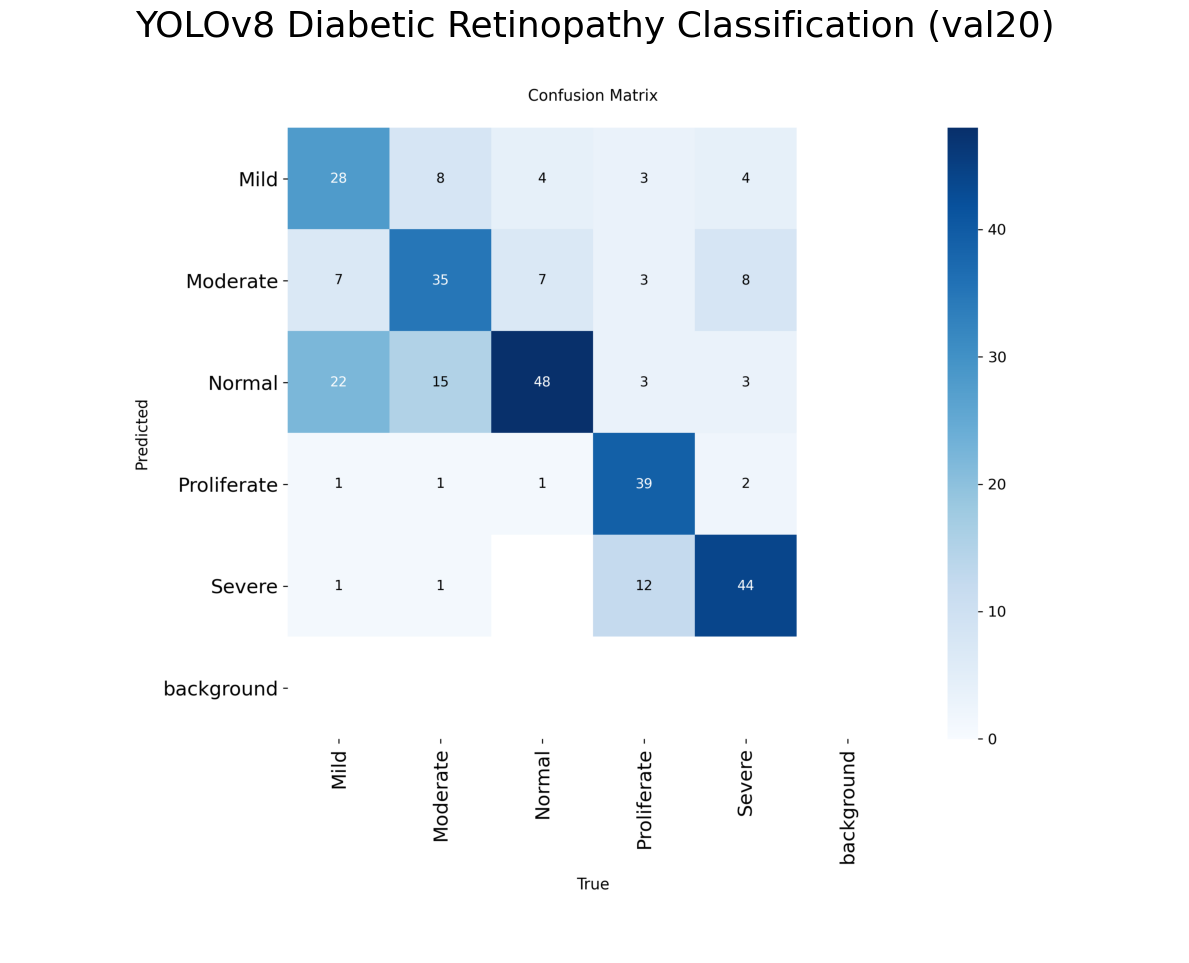

✅ Enhanced confusion matrix from: /opt/homebrew/runs/classify/val20/confusion_matrix.png


In [10]:
val_dir = '/opt/homebrew/runs/classify/val20'
confusion_path = os.path.join(val_dir, 'confusion_matrix.png')

if os.path.exists(confusion_path):
    # img = plt.imread(confusion_path)
    # plt.figure(figsize=(10, 8))
    # plt.imshow(img)

    # # plt.title('YOLOv8 DR Confusion Matrix (from val20)')
    # plt.suptitle('YOLOv8 DR Validation', fontsize=24)  # Subtitle example
    # plt.title('Confusion Matrix', fontsize=18)
    # plt.xlabel('True', fontsize=30)       # X-axis label
    # plt.ylabel('Predicted', fontsize=20)  # Y-axis label
    # plt.axis('off')
    # plt.show()
    # print(f"✅ Confusion matrix displayed from: {confusion_path}")

    img = plt.imread(confusion_path)
    fig = plt.figure(figsize=(12, 10))  # Slightly larger
    plt.imshow(img)
    fig.suptitle('YOLOv8 Diabetic Retinopathy Classification (val20)', fontsize=26)
    plt.xlabel('Predicted Class', fontsize=22, fontweight='bold', labelpad=15)
    plt.ylabel('True Class', fontsize=22, fontweight='bold', labelpad=20)
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"✅ Enhanced confusion matrix from: {confusion_path}")

else:
    print("❌ No confusion_matrix.png found - check directory contents")

### 5.3. Determining the F1 Score from the confusion matrix

In [28]:
y_true, y_pred = [], []
for i in range(cm.shape[0]):  # True class
    for j in range(cm.shape[1]):  # Predicted class
        n = int(cm[i, j])  # Cell count as int
        y_true.extend([i] * n)
        y_pred.extend([j] * n)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(f"Total samples: {len(y_true)}")  # Should be 300

f1_macro = f1_score(y_true, y_pred, average='macro')
print("Macro F1 Score:", f1_macro)
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Total samples: 300
Macro F1 Score: 0.6473785215698176

Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.60      0.53        47
           1       0.58      0.58      0.58        60
           2       0.80      0.53      0.64        91
           3       0.65      0.89      0.75        44
           4       0.72      0.76      0.74        58

    accuracy                           0.65       300
   macro avg       0.65      0.67      0.65       300
weighted avg       0.67      0.65      0.65       300



### 5.4. Visual Model Validation

Found 3 validation batch images with bounding boxes


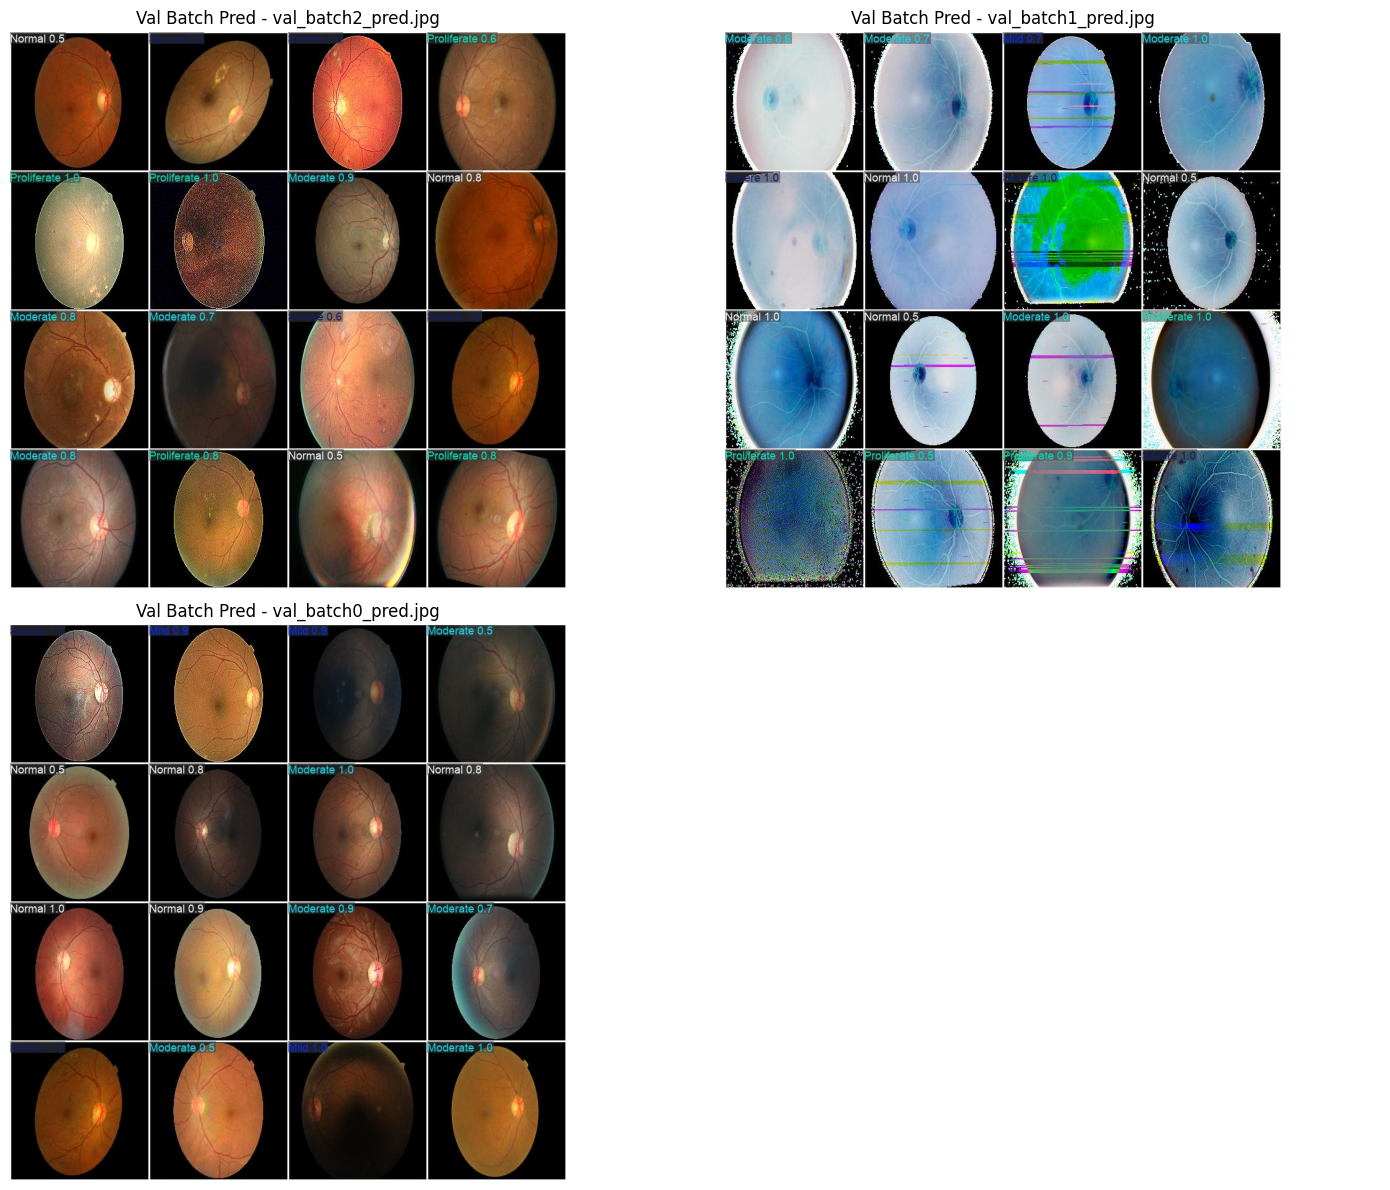

In [31]:
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path

# Your validation directory
val_dir = Path('/opt/homebrew/runs/classify/val20')  # Update to your latest val dir

# Find all prediction images with bounding boxes
pred_images = glob.glob(str(val_dir / 'val_batch*_pred.jpg')) + \
              glob.glob(str(val_dir / 'val_batch*_pred.png'))

print(f"Found {len(pred_images)} validation batch images with bounding boxes")

# Display first 4 (or all if fewer)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for ax in axes[len(pred_images[:4]):]:
    ax.axis('off')

for i, img_path in enumerate(pred_images[:4]):
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'Val Batch Pred - {Path(img_path).name}', fontsize=12)
    axes[i].axis('off')



plt.tight_layout()
plt.show()


## 6. Testing the model

In [32]:
# Path to an image you want to classify
image_path = "./oct_100_per_class/val/Severe/11292_right-rotated1.png" # Took a image from the severe class to test the model prediction

# Run prediction
results = model.predict(image_path)

# Get top-1 class index and score
top1_class = results[0].probs.top1  # predicted class index
top1_conf = results[0].probs.top1conf  # confidence score

# Get readable class name (from model.names mapping)
class_name = model.names[top1_class]
print(f"Predicted class: {class_name} (index: {top1_class}) with confidence {top1_conf:.2f}")


image 1/1 /Users/nilotpalbose/Documents/University/Design Workshop/Diabetic Retinopathy/oct_100_per_class/val/Severe/11292_right-rotated1.png: 224x224 Severe 0.98, Proliferate 0.02, Moderate 0.00, Mild 0.00, Normal 0.00, 445.2ms
Speed: 63.0ms preprocess, 445.2ms inference, 3.8ms postprocess per image at shape (1, 3, 224, 224)
Predicted class: Severe (index: 4) with confidence 0.98
